<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab%203/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install wbgapi

In [15]:
import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

country_codes = ['SGP','HIC','WLD']

indicators = {
    'NY.GDP.PCAP.KD': 'GDP_Per_Capita_Const',     # Standard of Living
    'SL.TLF.CACT.ZS': 'Labor_Part_Rate',          # Labor Supply
    'SL.UEM.TOTL.ZS': 'Unemployment_Rate',        # Labor Friction
    'SL.TLF.TOTL.IN': 'Labor_Force_Total',        # Total Workers
    'NY.GDP.MKTP.KD': 'GDP_Const',                # Economic Size
    'FP.CPI.TOTL.ZG': 'Inflation_CPI',            # Stability
    'NY.GDS.TOTL.ZS': 'Gross_Dom_Savings',        # Savings
    'NE.GDI.TOTL.ZS': 'Gross_Cap_Formation',      # Investment
    'NE.EXP.GNFS.ZS': 'Exports_GDP',              # Exports
    'NE.IMP.GNFS.ZS': 'Imports_GDP',              # Imports
    'GC.TAX.TOTL.GD.ZS': 'Tax_Rev_GDP',           # Gov Revenue
    'NE.CON.GOVT.ZS': 'Gov_Exp_GDP'               # Gov Spending
}

In [16]:
# 1. Fetch Data
print("Fetching data...")
df_raw = wb.data.DataFrame(indicators, economy=country_codes, time=range(2000, 2025))

# 2. Transpose (Flip Rows/Cols)
df = df_raw.T

# 3. Clean Index
df.index = df.index.str.replace('YR', '').astype(int)
df.index.name = 'Year'
df = df.sort_index()

# 4. Rename Columns
df.rename(columns=indicators, level=1, inplace=True)

# 5. Extract Guatemala for specific calculations
df_sgp = df.xs('SGP', axis=1, level=0).copy()

Fetching data...


In [17]:
# 1. Natural Rate of Unemployment (5-Year MA)
df_sgp['Natural_Rate_Unemp'] = df_sgp['Unemployment_Rate'].rolling(window=5).mean()

# 2. Productivity (Output per Worker)
df_sgp['Productivity'] = df_sgp['GDP_Const'] / df_sgp['Labor_Force_Total']

# 3. Net Capital Outflow (Exports - Imports)
df_sgp['NCO'] = df_sgp['Exports_GDP'] - df_sgp['Imports_GDP']

# 4. Budget Balance (Tax - Spending)
df_sgp['Budget_Balance'] = df_sgp['Tax_Rev_GDP'] - df_sgp['Gov_Exp_GDP']

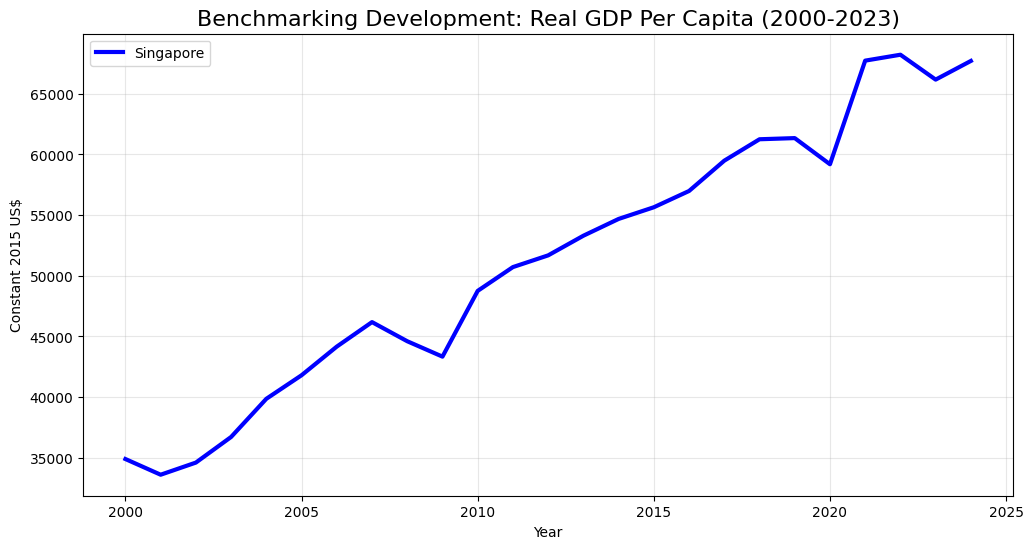

In [18]:
plt.figure(figsize=(12, 6))
# Plot ONLY Singapore
plt.plot(df.index, df[('SGP', 'GDP_Per_Capita_Const')], label='Singapore', color='blue', linewidth=3)
plt.title('Benchmarking Development: Real GDP Per Capita (2000-2023)', fontsize=16)
plt.ylabel('Constant 2015 US$')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

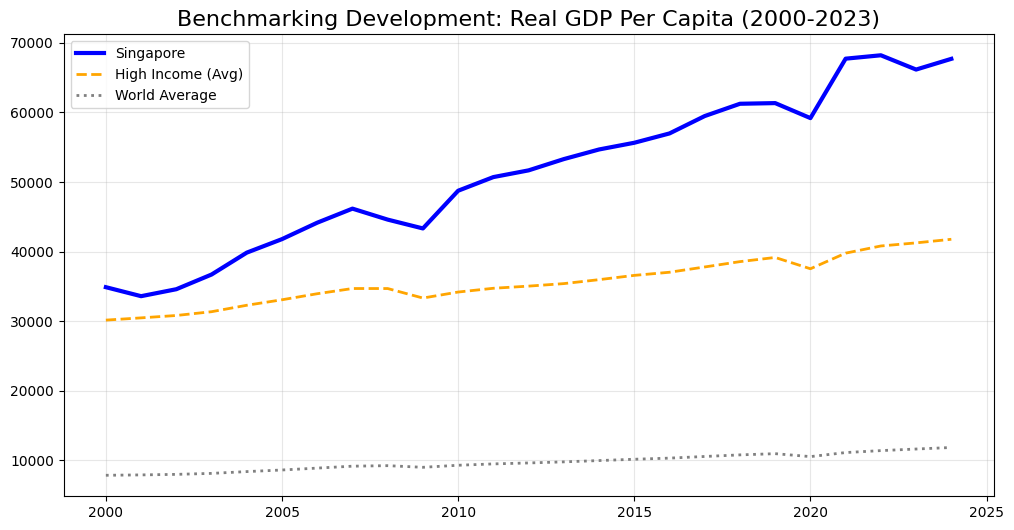

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df[('SGP', 'GDP_Per_Capita_Const')], label='Singapore', color='blue', linewidth=3)
plt.plot(df.index, df[('HIC', 'GDP_Per_Capita_Const')], label='High Income (Avg)', color='orange', linestyle='--', linewidth=2)
plt.plot(df.index, df[('WLD', 'GDP_Per_Capita_Const')], label='World Average', color='grey', linestyle=':', linewidth=2)

plt.title('Benchmarking Development: Real GDP Per Capita (2000-2023)', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

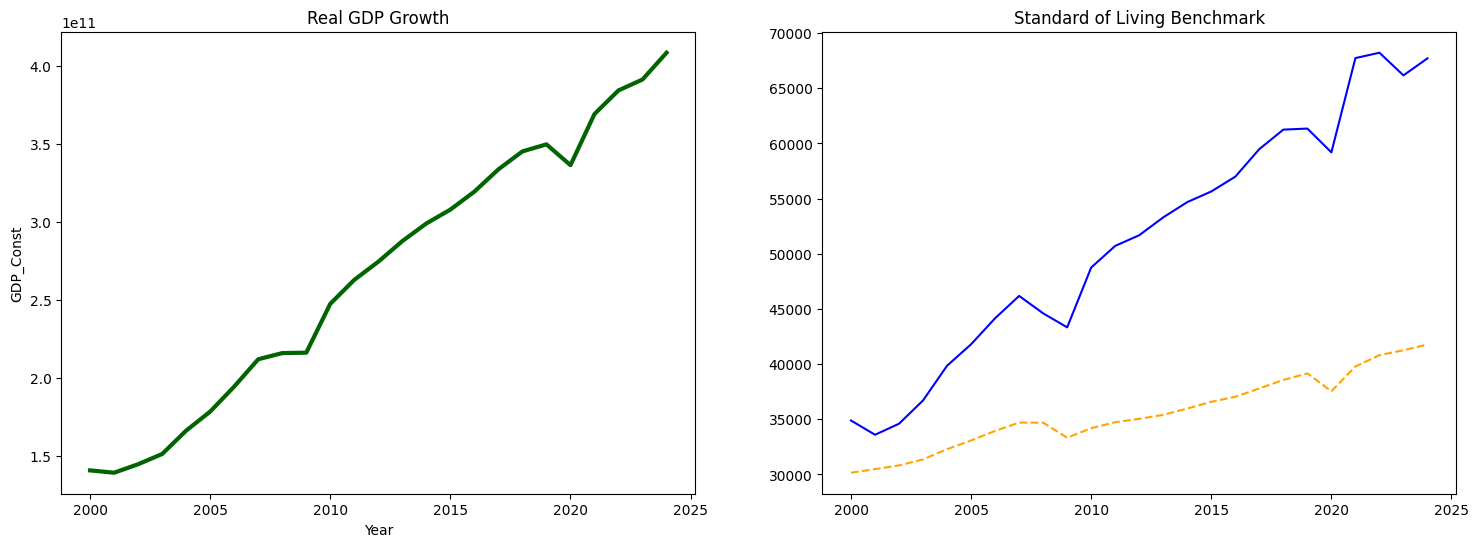

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Chart A: Total GDP
sns.lineplot(data=df_sgp, x=df_sgp.index, y='GDP_Const', color='darkgreen', linewidth=3, ax=ax1)
ax1.set_title('Real GDP Growth')

# Chart B: GDP Per Capita Benchmark
ax2.plot(df.index, df[('SGP', 'GDP_Per_Capita_Const')], color='blue')
ax2.plot(df.index, df[('HIC', 'GDP_Per_Capita_Const')], color='orange', linestyle='--')
ax2.set_title('Standard of Living Benchmark')
plt.show()

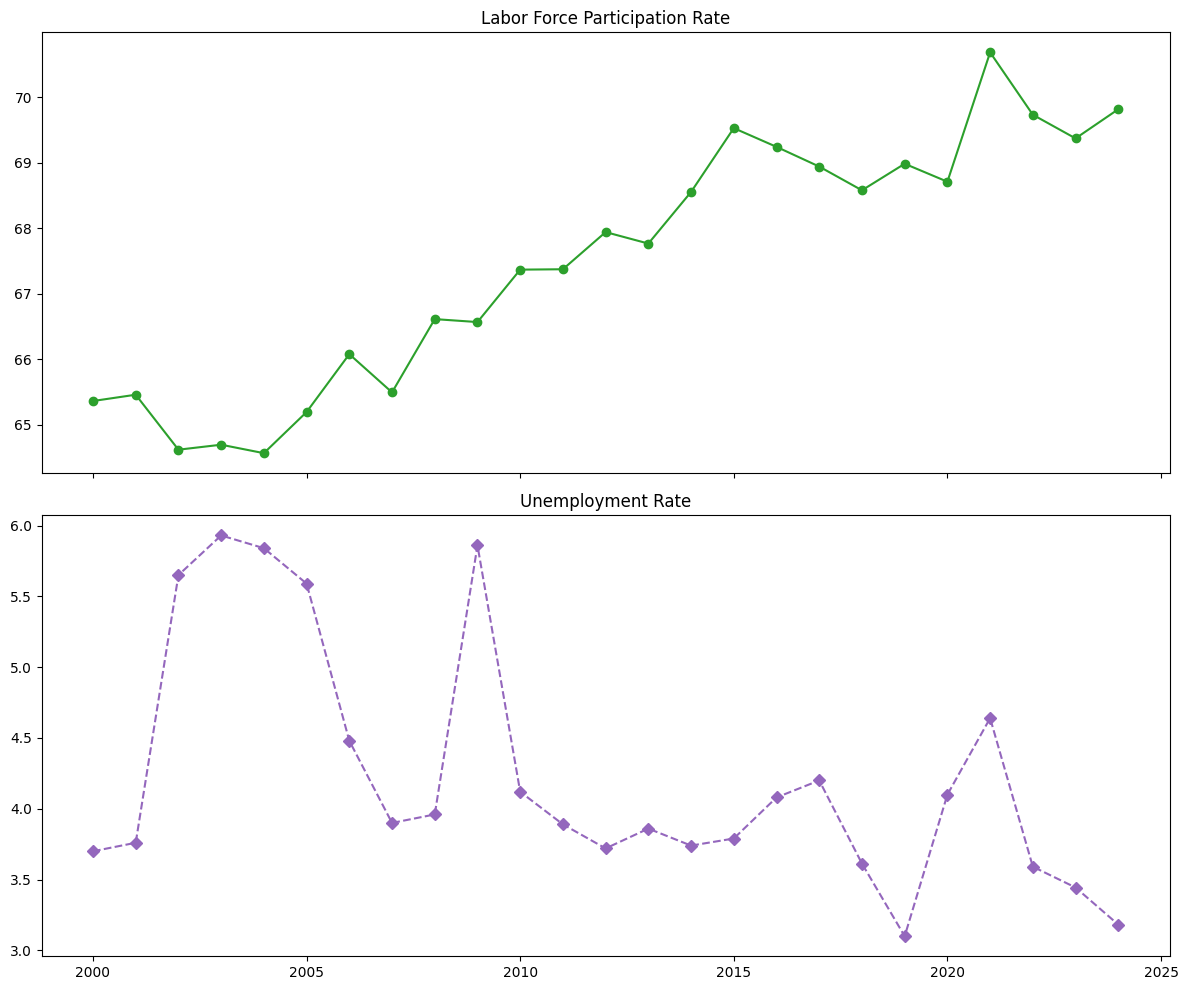

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top: Participation
ax1.plot(df_sgp.index, df_sgp['Labor_Part_Rate'], color='tab:green', marker='o')
ax1.set_title('Labor Force Participation Rate')

# Bottom: Unemployment
ax2.plot(df_sgp.index, df_sgp['Unemployment_Rate'], color='tab:purple', marker='D', linestyle='--')
ax2.set_title('Unemployment Rate')
plt.tight_layout()
plt.show()

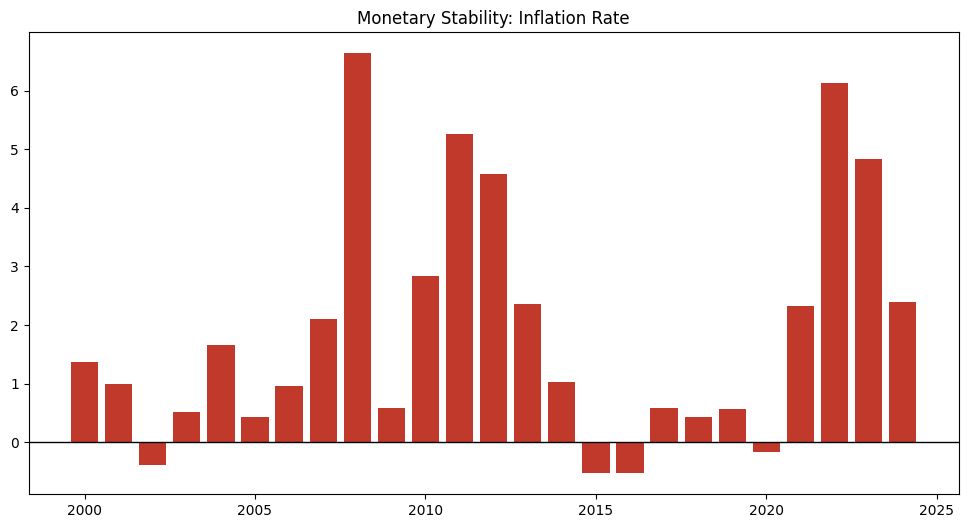

In [22]:
plt.figure(figsize=(12, 6))

plt.bar(df_sgp.index, df_sgp['Inflation_CPI'], color='#c0392b')

plt.axhline(0, color='black', linewidth=1)
plt.title('Monetary Stability: Inflation Rate')
plt.show()

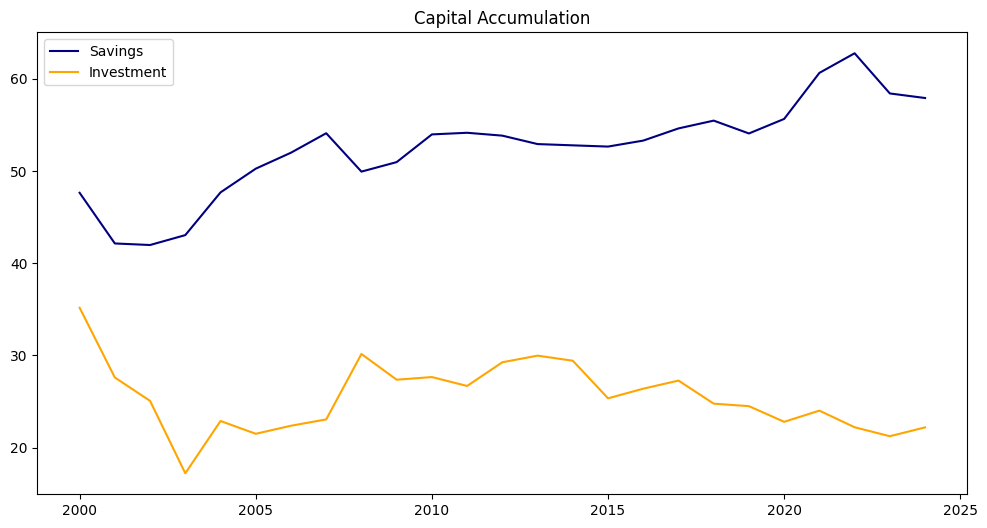

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(df_sgp.index, df_sgp['Gross_Dom_Savings'], label='Savings', color='navy')
plt.plot(df_sgp.index, df_sgp['Gross_Cap_Formation'], label='Investment', color='orange')
plt.title('Capital Accumulation')
plt.legend()
plt.show()

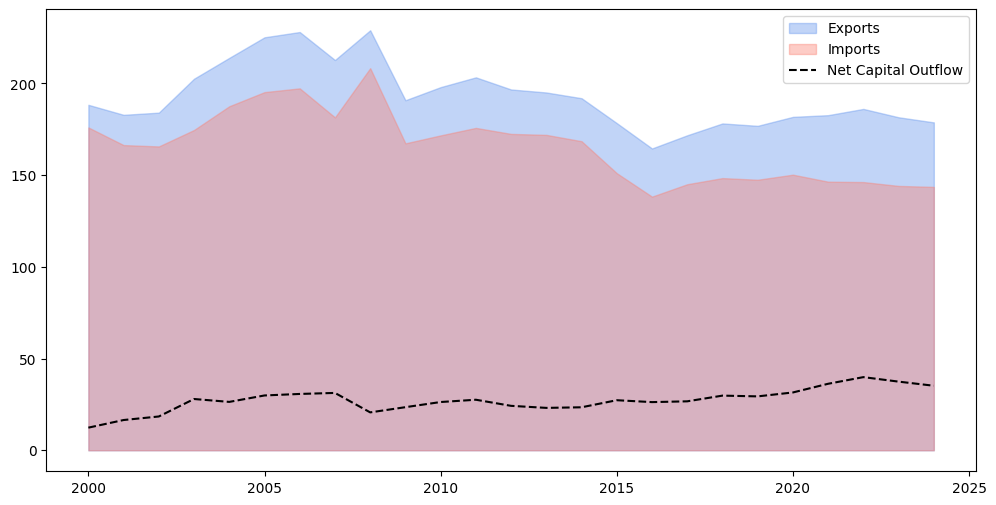

In [25]:
plt.figure(figsize=(12, 6))
plt.fill_between(df_sgp.index, df_sgp['Exports_GDP'], color='cornflowerblue', alpha=0.4, label='Exports')
plt.fill_between(df_sgp.index, df_sgp['Imports_GDP'], color='salmon', alpha=0.4, label='Imports')
plt.plot(df_sgp.index, df_sgp['NCO'], color='black', linestyle='--', label='Net Capital Outflow')
plt.legend()
plt.show()

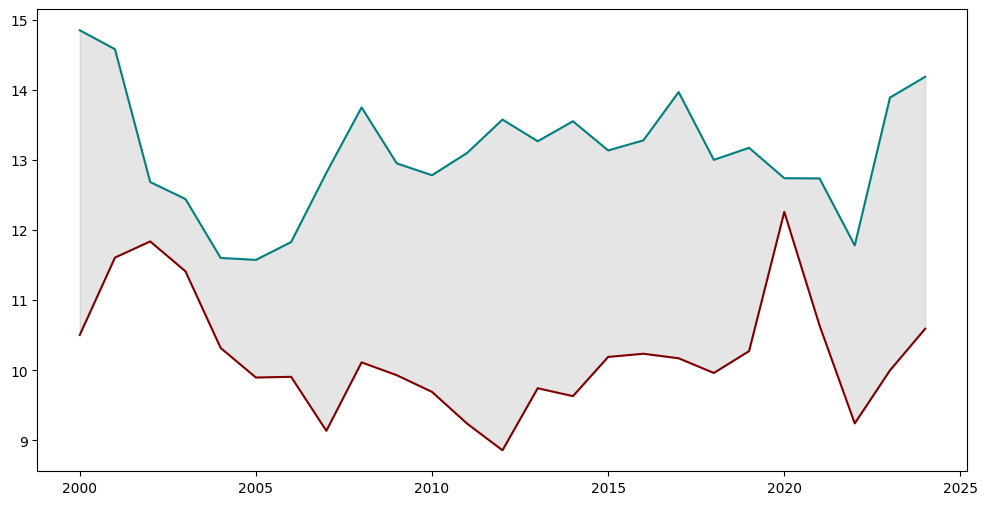

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(df_sgp.index, df_sgp['Tax_Rev_GDP'], label='Revenue', color='teal')
plt.plot(df_sgp.index, df_sgp['Gov_Exp_GDP'], label='Expenditure', color='maroon')
plt.fill_between(df_sgp.index, df_sgp['Tax_Rev_GDP'], df_sgp['Gov_Exp_GDP'], color='gray', alpha=0.2)
plt.show()

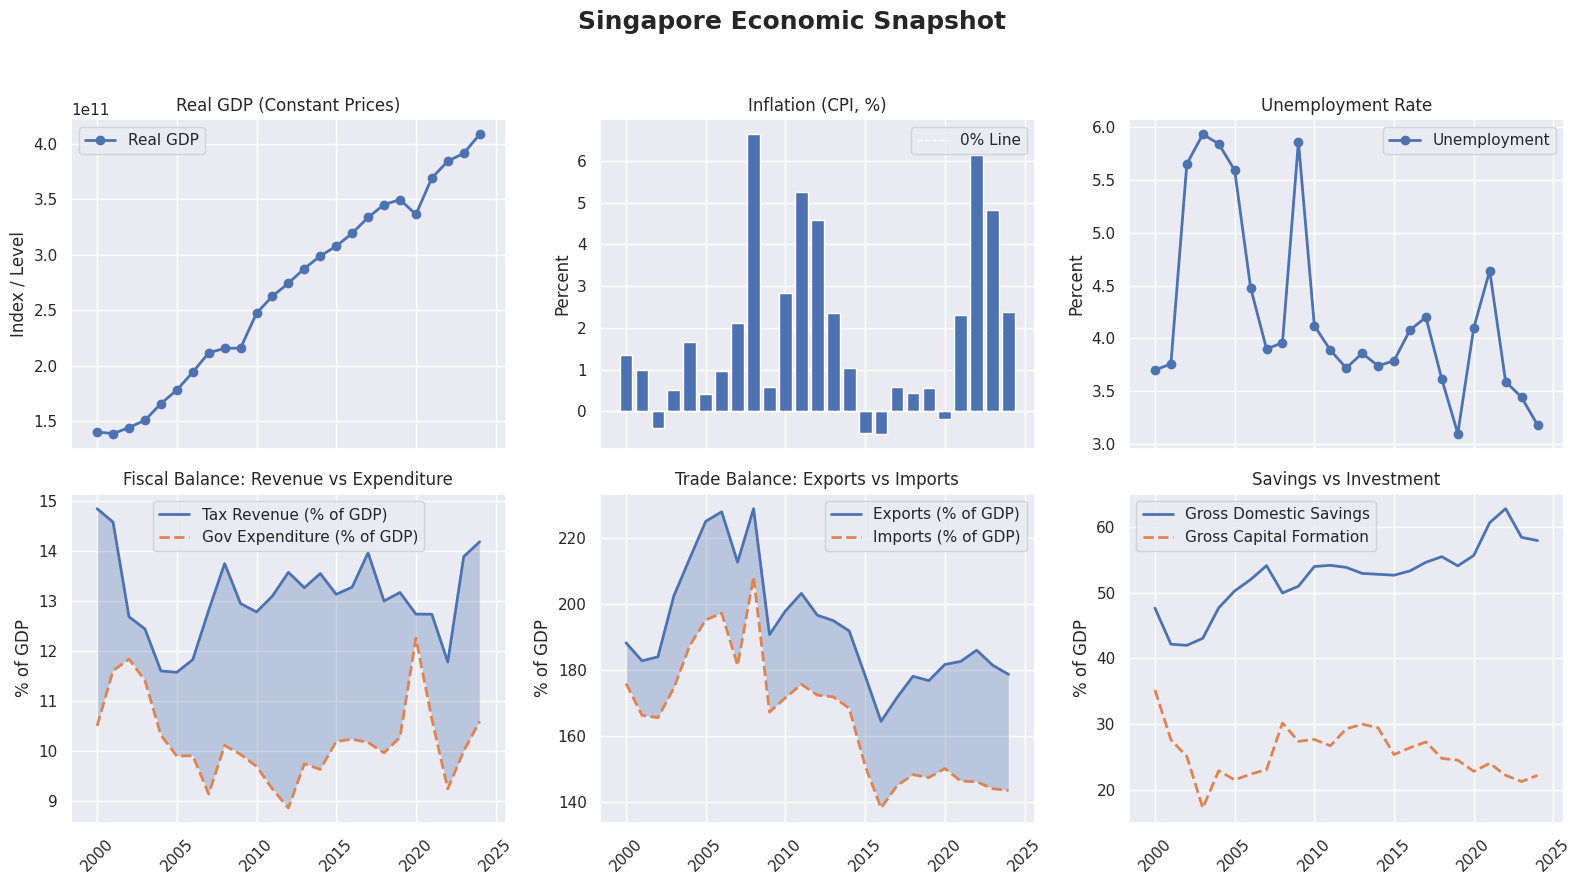

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use('dark_background')
sns.set_theme(style="darkgrid")

# Assume df_sgp index is time (e.g. Year or Datetime)
x = df_sgp.index

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)

# -------------------
# Top Left: Real GDP
# -------------------
ax = axes[0, 0]
ax.plot(x, df_sgp['GDP_Const'], marker='o', linewidth=2, label='Real GDP')
ax.set_title('Real GDP (Constant Prices)')
ax.set_ylabel('Index / Level')
ax.legend(loc='best')

# -----------------------
# Top Middle: Inflation
# -----------------------
ax = axes[0, 1]
ax.bar(x, df_sgp['Inflation_CPI'])
ax.axhline(0, color='white', linestyle='--', linewidth=1)
ax.set_title('Inflation (CPI, %)')
ax.set_ylabel('Percent')
ax.legend(['0% Line'], loc='best')

# --------------------------
# Top Right: Unemployment
# --------------------------
ax = axes[0, 2]
ax.plot(x, df_sgp['Unemployment_Rate'], marker='o', linewidth=2, label='Unemployment')
ax.set_title('Unemployment Rate')
ax.set_ylabel('Percent')
ax.legend(loc='best')

# -------------------------
# Bottom Left: Fiscal Bal.
# -------------------------
ax = axes[1, 0]
tax = df_sgp['Tax_Rev_GDP']
gov = df_sgp['Gov_Exp_GDP']

ax.plot(x, tax, linewidth=2, label='Tax Revenue (% of GDP)')
ax.plot(x, gov, linewidth=2, linestyle='--', label='Gov Expenditure (% of GDP)')
ax.fill_between(x, tax, gov, alpha=0.3)

ax.set_title('Fiscal Balance: Revenue vs Expenditure')
ax.set_ylabel('% of GDP')
ax.legend(loc='best')

# -------------------------
# Bottom Middle: Trade Bal.
# -------------------------
ax = axes[1, 1]
exp_ = df_sgp['Exports_GDP']
imp_ = df_sgp['Imports_GDP']

ax.plot(x, exp_, linewidth=2, label='Exports (% of GDP)')
ax.plot(x, imp_, linewidth=2, linestyle='--', label='Imports (% of GDP)')
ax.fill_between(x, exp_, imp_, alpha=0.3)

ax.set_title('Trade Balance: Exports vs Imports')
ax.set_ylabel('% of GDP')
ax.legend(loc='best')

# -----------------------------------
# Bottom Right: Savings vs Investment
# -----------------------------------
ax = axes[1, 2]
sav = df_sgp['Gross_Dom_Savings']
inv = df_sgp['Gross_Cap_Formation']

ax.plot(x, sav, linewidth=2, label='Gross Domestic Savings')
ax.plot(x, inv, linewidth=2, linestyle='--', label='Gross Capital Formation')

ax.set_title('Savings vs Investment')
ax.set_ylabel('% of GDP')
ax.legend(loc='best')

# ---------------
# Global tweaks
# ---------------
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Singapore Economic Snapshot', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()